# Equity Feature Engineering

The original chapter used Japanese equities. This modern notebook keeps the same feature-engineering pattern on a local synthetic equity universe.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from tree_model_utils import (
    FEATURES,
    compare_bagging,
    ensure_output_dir,
    fit_decision_tree,
    fit_signal_model,
    long_short_backtest,
    make_equity_panel,
    signal_quality,
    tune_random_forest,
)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()


In [2]:
panel = make_equity_panel(seed=115)
feature_summary = panel[FEATURES + ['target_5d']].describe().T
feature_summary.to_csv(OUTPUT / 'feature_summary.csv')
feature_summary

,count,mean,std,min,25%,50%,75%,max
momentum_21,"55,040.0000",0.0059,0.0678,-0.2498,-0.0396,0.0034,0.0489,0.2906
momentum_63,"55,040.0000",0.0222,0.1142,-0.3526,-0.0547,0.0152,0.0922,0.6301
volatility_21,"55,040.0000",0.0154,0.0028,0.0052,0.0134,0.0152,0.0172,0.0283
reversal_5,"55,040.0000",-0.0014,0.0337,-0.1399,-0.0237,-0.0008,0.0212,0.1366
sector_beta,"55,040.0000",0.9771,0.2317,0.4461,0.8057,0.9372,1.1547,1.5518
quality,"55,040.0000",-0.1153,0.8865,-2.3429,-0.8109,-0.1344,0.4720,1.7937
target_5d,"55,040.0000",0.0012,0.0337,-0.1366,-0.0214,0.0006,0.0236,0.1399


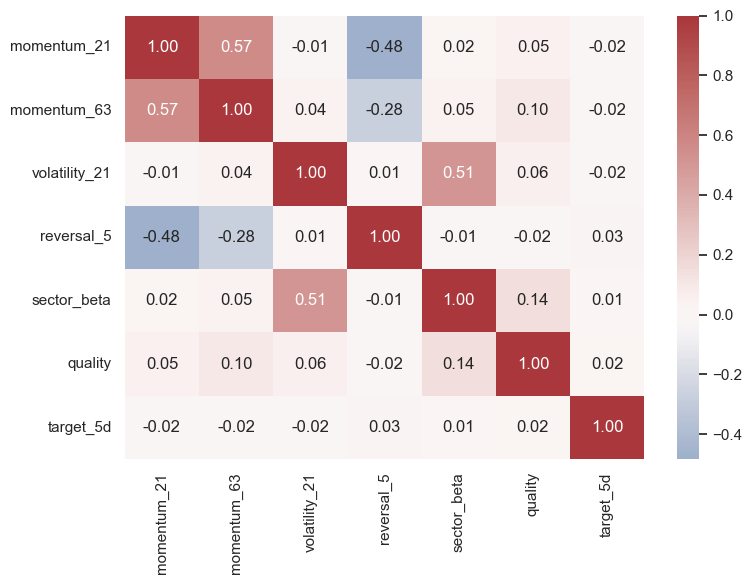

In [3]:
corr = panel[FEATURES + ['target_5d']].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, cmap='vlag', center=0, annot=True, fmt='.2f', ax=ax)
plt.tight_layout()